In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

DATA_PATH = "/content/drive/MyDrive/datasets_aligned/NASDAQCOM.csv"

print("DATA_PATH exists:", os.path.exists(DATA_PATH))
# print("Files in folder:")
# print(os.listdir(DATA_PATH))

DATA_PATH exists: True


Loading data...
Computing returns...
Splitting data...
Running walk-forward ARIMA...
Processed 50/500 test points
Processed 100/500 test points
Processed 150/500 test points
Processed 200/500 test points
Processed 250/500 test points
Processed 300/500 test points
Processed 350/500 test points
Processed 400/500 test points
Processed 450/500 test points
Processed 500/500 test points

===== RESULTS =====
MSE: 0.012445
MAE: 0.065324
Direction Accuracy: 0.540000
Direction F1: 0.649390


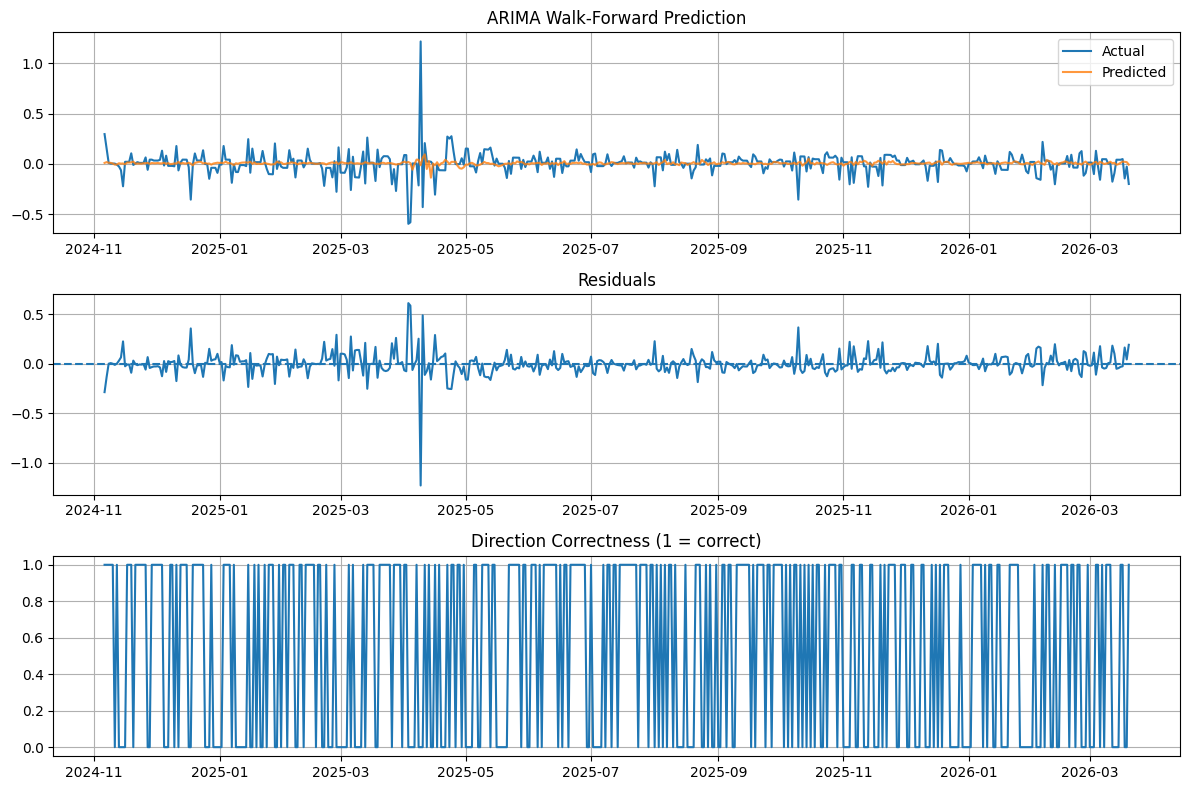

In [7]:

warnings.filterwarnings("ignore")

TRAIN_RATIO = 0.8
ARIMA_ORDER = (5, 0, 1)
ROLLING_WINDOW_SIZE = 1000
MAX_TEST_POINTS = 500


def load_data():
    df = pd.read_csv(DATA_PATH)
    df["date"] = pd.to_datetime(df["date"])
    return df


def get_return(df):
    df = df.copy()
    df["return"] = df["NASDAQCOM"].pct_change() * 10
    df = df.dropna().reset_index(drop=True)
    return df


def split_data(df):
    split_idx = int(len(df) * TRAIN_RATIO)

    train = df["return"].iloc[:split_idx].reset_index(drop=True)
    test = df["return"].iloc[split_idx:].reset_index(drop=True)
    test_dates = df["date"].iloc[split_idx:].reset_index(drop=True)

    return train, test, test_dates


def restrict_test(test, dates):
    if len(test) > MAX_TEST_POINTS:
        test = test.iloc[-MAX_TEST_POINTS:].reset_index(drop=True)
        dates = dates.iloc[-MAX_TEST_POINTS:].reset_index(drop=True)
    return test, dates


def walk_forward(train, test):
    history = list(train)
    predictions = []

    for i, actual in enumerate(test):
        hist = history[-ROLLING_WINDOW_SIZE:]

        try:
            model = ARIMA(hist, order=ARIMA_ORDER)
            model_fit = model.fit()
            forecast = model_fit.forecast(steps=1)
            pred = float(np.asarray(forecast)[0])
        except:
            pred = float(np.mean(hist))

        predictions.append(pred)
        history.append(float(actual))

        if (i + 1) % 50 == 0 or (i + 1) == len(test):
            print(f"Processed {i + 1}/{len(test)} test points")

    return np.array(predictions)


def direction_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))


def direction_f1(y_true, y_pred):
    true = (y_true > 0).astype(int)
    pred = (y_pred > 0).astype(int)

    tp = np.sum((true == 1) & (pred == 1))
    fp = np.sum((true == 0) & (pred == 1))
    fn = np.sum((true == 1) & (pred == 0))

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0

    return 2 * precision * recall / (precision + recall) if (precision + recall) else 0

def plot_results(dates, y_true, y_pred):
    residuals = y_pred - y_true

    plt.figure(figsize=(12, 8))

    plt.subplot(3, 1, 1)
    plt.plot(dates, y_true, label="Actual")
    plt.plot(dates, y_pred, label="Predicted", alpha=0.8)
    plt.title("ARIMA Walk-Forward Prediction")
    plt.legend()
    plt.grid(True)

    plt.subplot(3, 1, 2)
    plt.plot(dates, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Residuals")
    plt.grid(True)

    plt.subplot(3, 1, 3)
    correct = (np.sign(y_true) == np.sign(y_pred)).astype(int)
    plt.plot(dates, correct)
    plt.title("Direction Correctness (1 = correct)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    print("Loading data...")
    df = load_data()

    print("Computing returns...")
    df = get_return(df)

    print("Splitting data...")
    train, test, dates = split_data(df)

    test, dates = restrict_test(test, dates)

    print("Running walk-forward ARIMA...")
    preds = walk_forward(train, test)

    y_true = test.values
    mse = np.mean((y_true - preds) ** 2)
    mae = mean_absolute_error(y_true, preds)
    acc = direction_accuracy(y_true, preds)
    f1 = direction_f1(y_true, preds)

    print("\n===== RESULTS =====")
    print(f"MSE: {mse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"Direction Accuracy: {acc:.6f}")
    print(f"Direction F1: {f1:.6f}")

    plot_results(dates, y_true, preds)